In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')
import warnings
warnings.filterwarnings("ignore")

# pd.set_option("display.width", 150)
# pd.set_option("display.precision", 3)
# plt.rcParams["figure.figsize"] = (9, 4.2)
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.alpha"] = 0.3
# plt.rcParams["figure.dpi"] = 110

SEED = 42

In [4]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [5]:
df.shape

(12330, 18)

# EDA

## Первичная обработка

In [6]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  

In [7]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [52]:
target_feature = 'Revenue'

categ_features = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Month",
    "Weekend"
]

quant_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

print(set(categ_features + quant_features + [target_feature]) == set(df.columns.to_list()) and len(categ_features) + len(quant_features) + 1 == len(df.columns.to_list()))

True


In [9]:
print('Пропусков по столбцам')
print(f'{df.isnull().sum()}')

Пропусков по столбцам
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [10]:
df[df.duplicated()].sort_values(list(df.columns))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
659,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,2,5,1,1,Returning_Visitor,False,False
4552,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,May,2,2,2,3,Returning_Visitor,False,False
5199,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,May,2,2,2,3,Returning_Visitor,False,False


In [11]:
total_duplicates = df.duplicated().sum()
print(f"Всего дублирующихся строк: {total_duplicates}")
print(f"Процент от выборки {(total_duplicates / df.shape[0] * 100):.2f}%")
# df.drop_duplicates(inplace=True)

Всего дублирующихся строк: 125
Процент от выборки 1.01%


In [12]:
df.drop_duplicates(inplace=True)

## Распределение

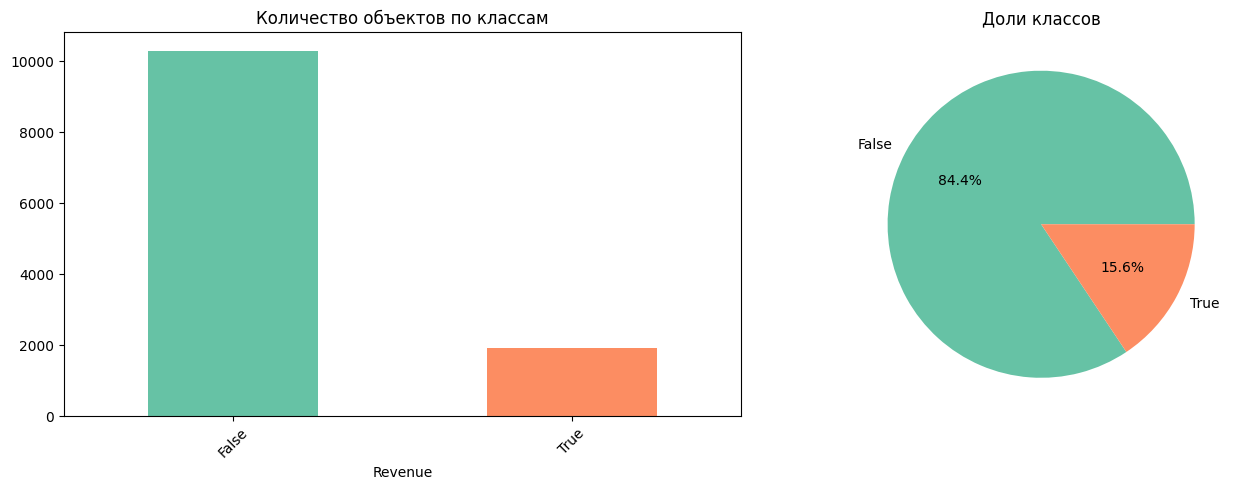

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_feature].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_feature].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

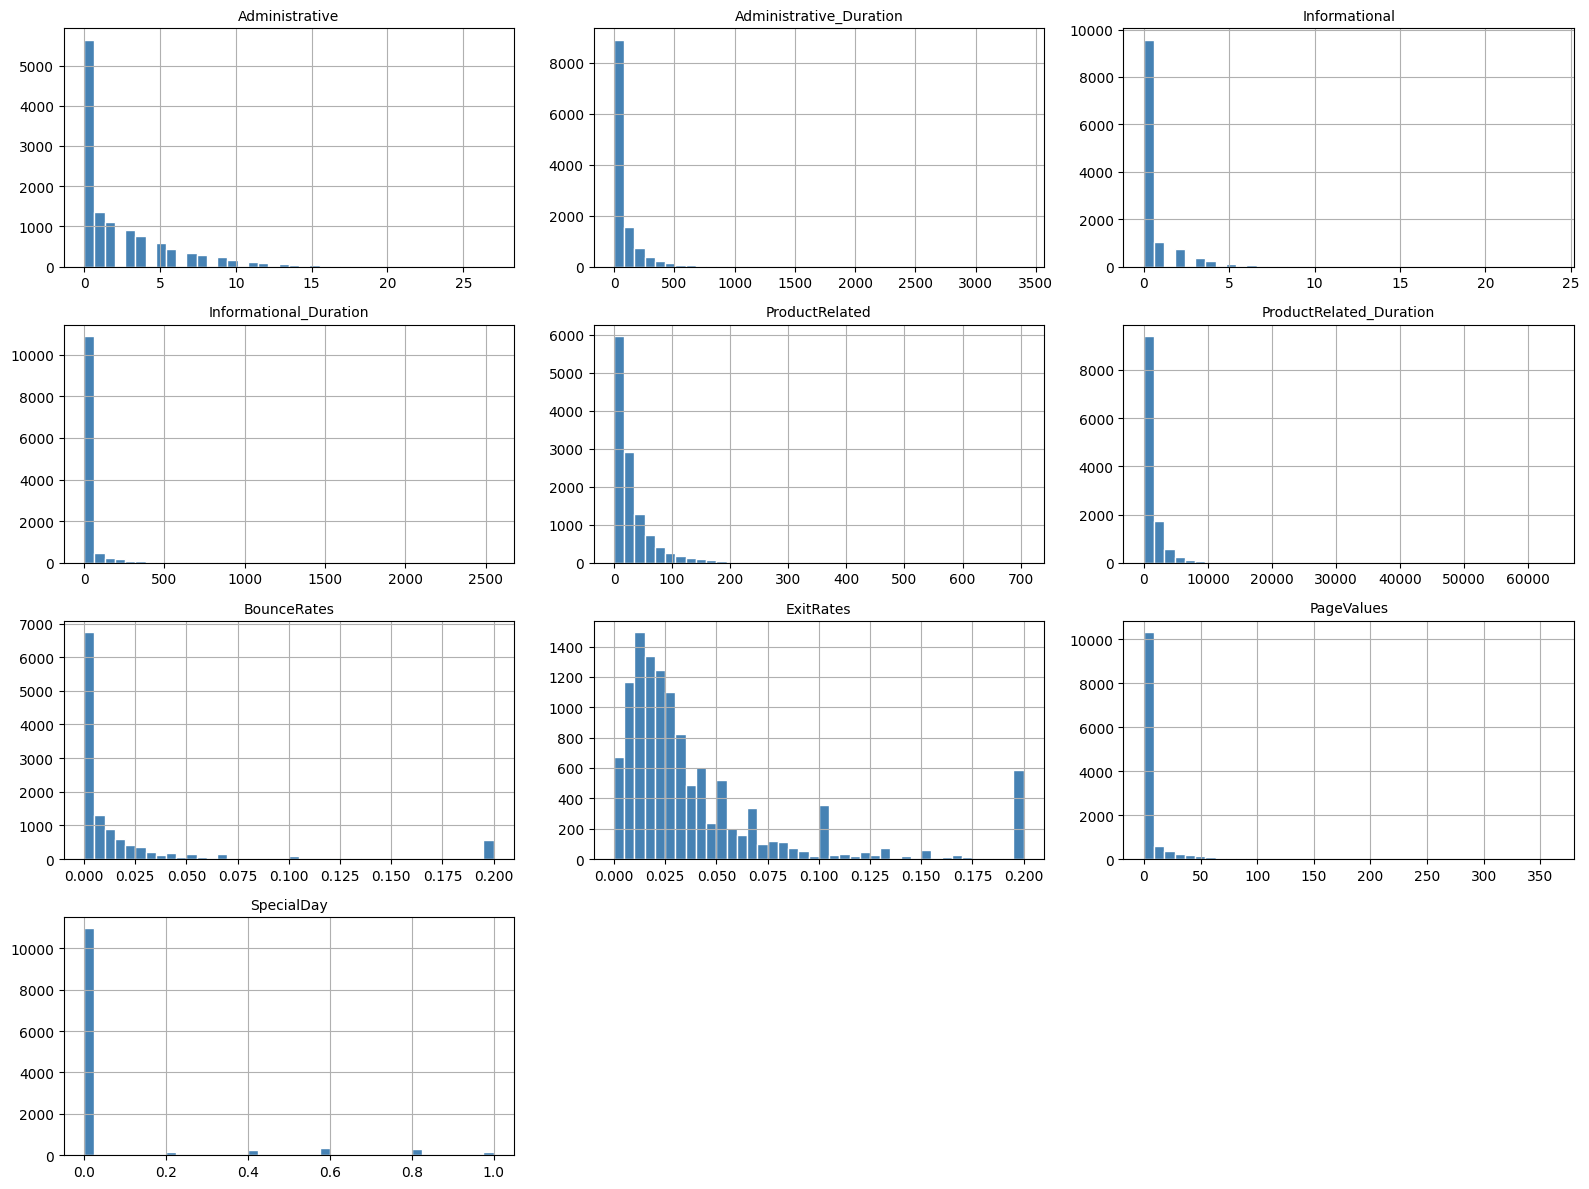

In [14]:
n_cols = len(quant_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
df[list(quant_features)].describe(percentiles=[.05, .25, .50, .75, .95, .99]).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,0.000000,1.000000,4.000000,9.000000,14.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,0.000000,9.000000,94.700000,352.208095,838.704889,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,0.000000,199.000000,722.379200,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,2.000000,8.000000,18.000000,38.000000,110.000000,221.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,0.000000,193.000000,608.942857,1477.154762,4312.956282,8704.271573,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.000000,0.002899,0.016667,0.149333,0.200000,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.004545,0.014231,0.025000,0.048529,0.173714,0.200000,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,0.000000,38.301457,86.108689,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,0.000000,0.600000,1.000000,1.000000


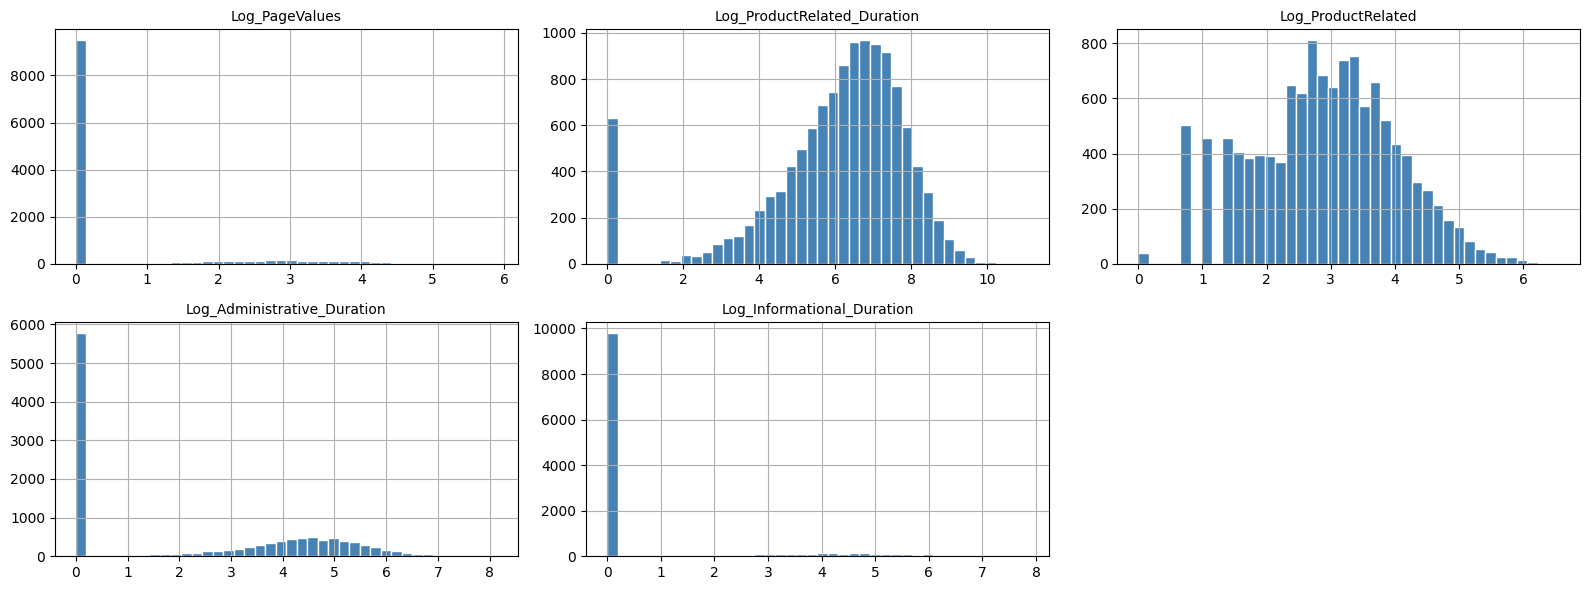

In [16]:
log_features = [
   'PageValues',
   'ProductRelated_Duration',
   'ProductRelated',
   'Administrative_Duration',
   'Informational_Duration',
]

n_cols = len(log_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(log_features):
    np.log1p(df[col]).hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title('Log_' + col, fontsize=10)

for j in range(len(log_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

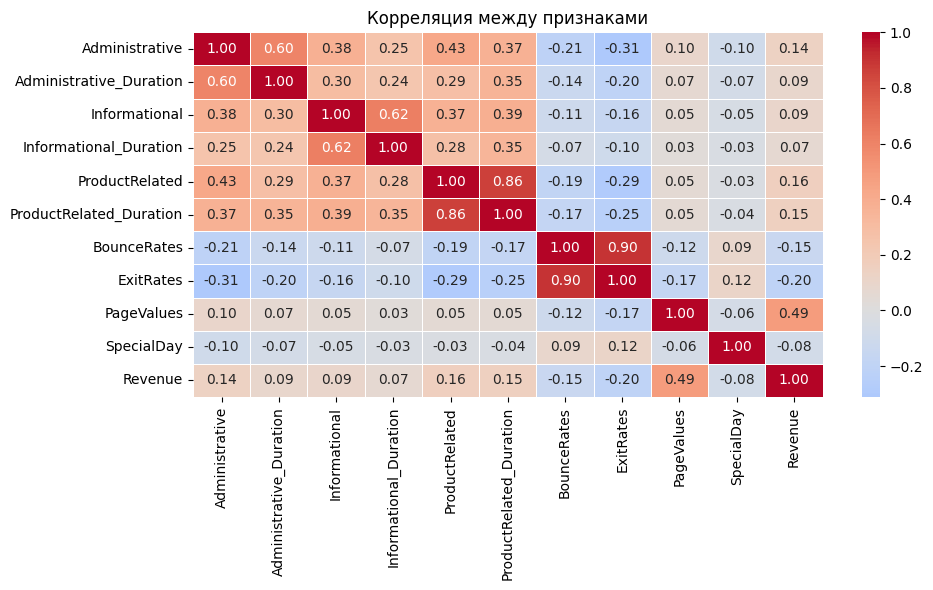

In [17]:
plt.figure(figsize=(10, 6))
corr = df[quant_features + [target_feature]].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

## Категориальные фичи

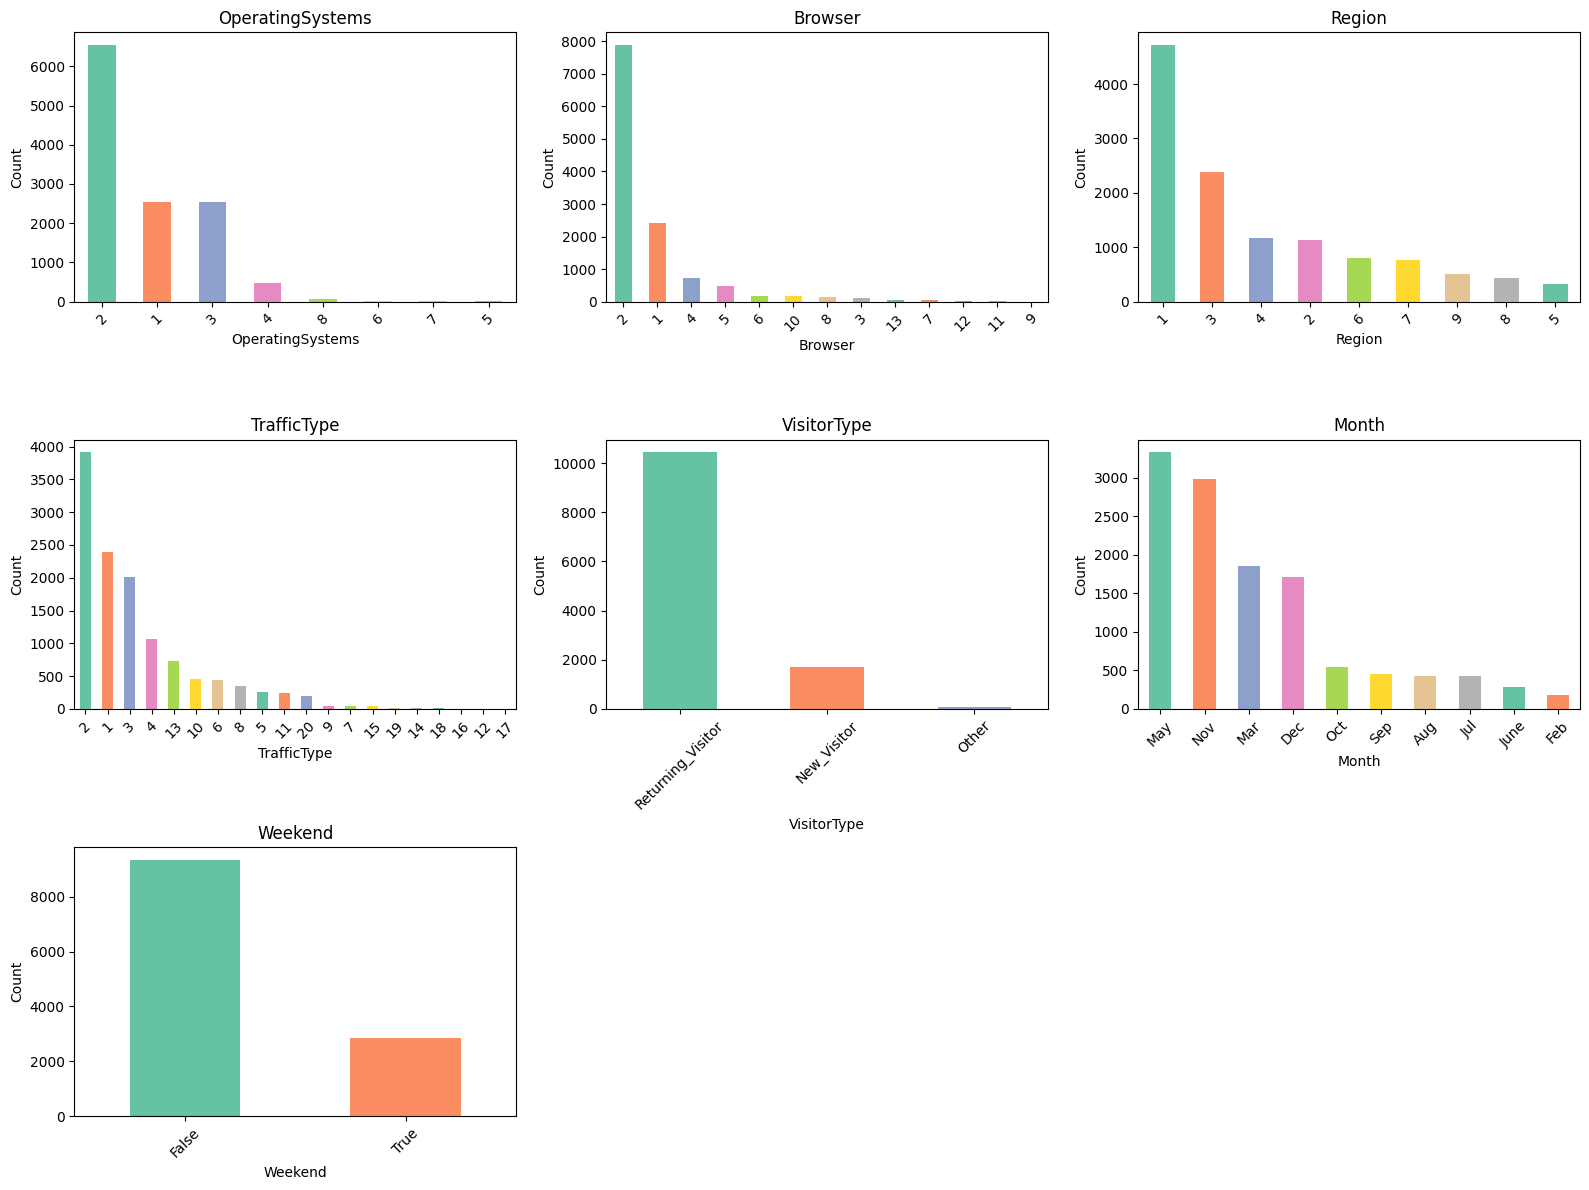

In [19]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    df[col].value_counts().plot.bar(ax=axes[i], color=sns.color_palette('Set2'))
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

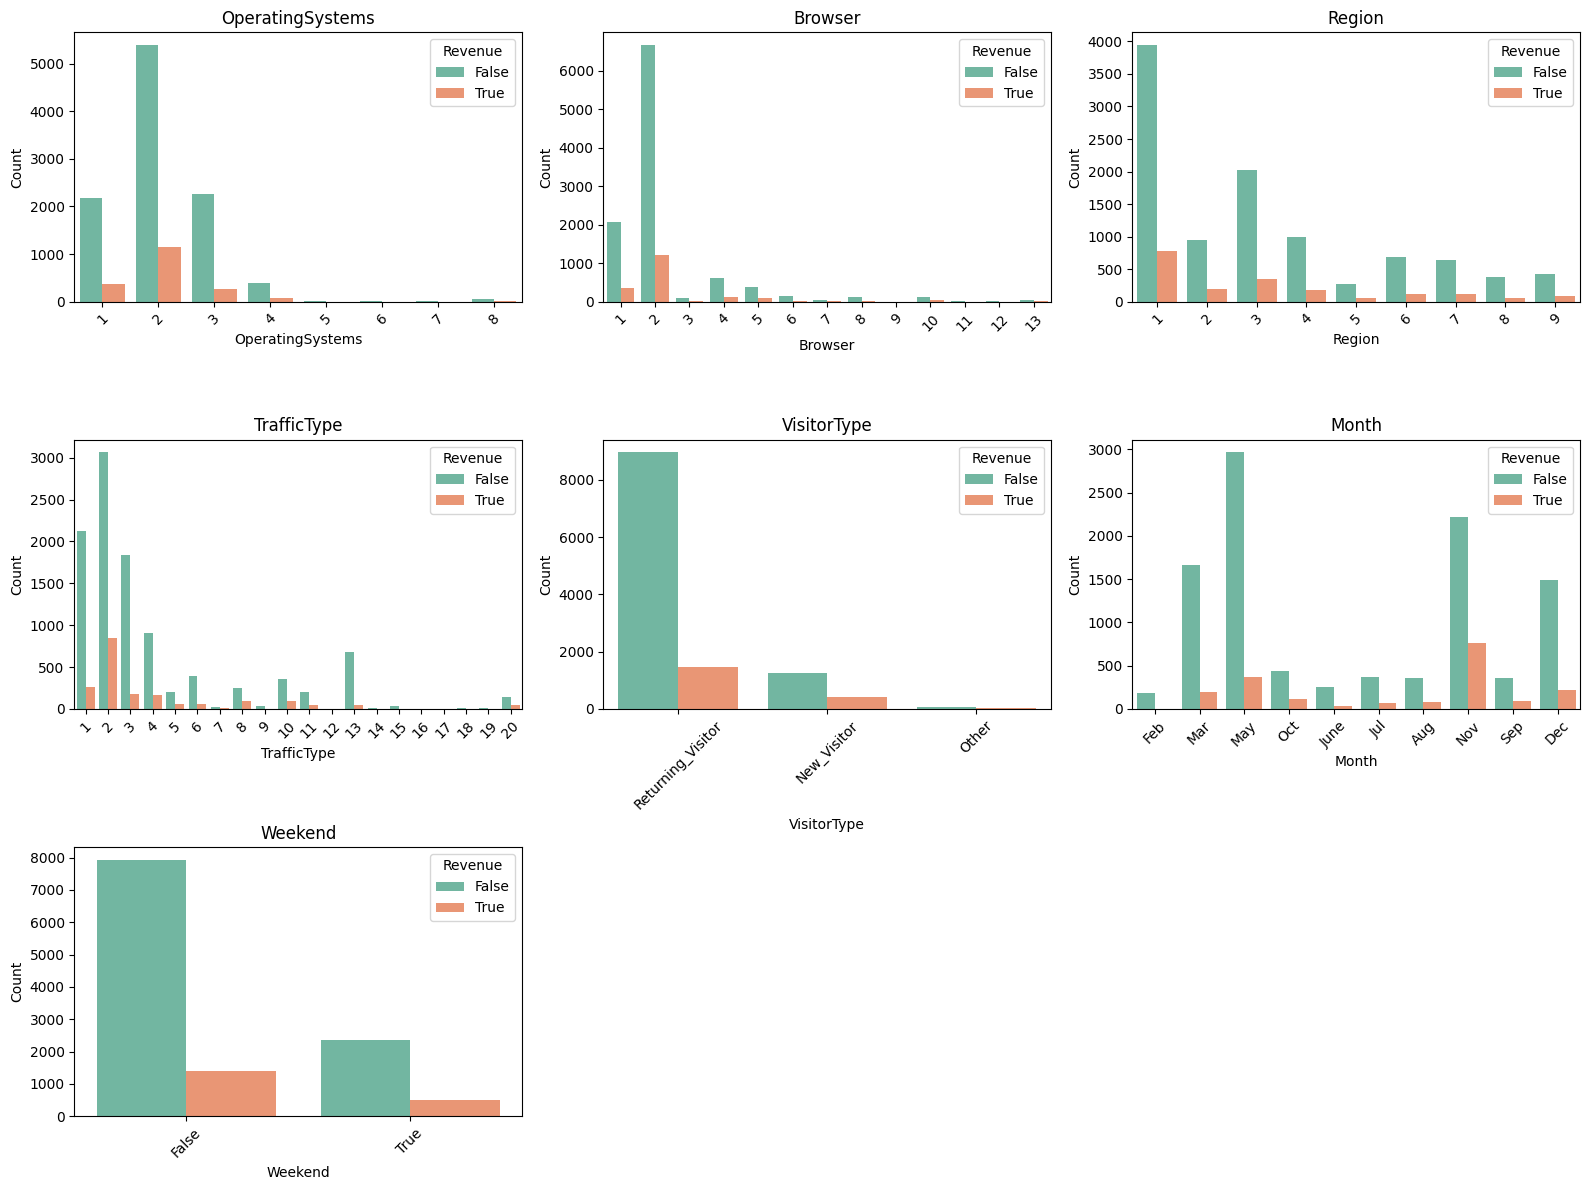

In [20]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    sns.countplot(data=df, x=col, hue=target_feature, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')
    axes[i].legend(title=target_feature)

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Feature engineering

In [30]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report
)


In [22]:
X = df.drop(columns=target_feature)
y = df[target_feature].astype(int)


In [23]:
X.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [24]:
binary_feature = [
    'Weekend'
]
for i in binary_feature:
    categ_features.remove(i)

X[binary_feature] = X[binary_feature].astype(int)
X[categ_features] = X[categ_features].astype('str')
X.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [25]:
for col in (categ_features):
    counts = X[col].value_counts()
    rare_categories = counts[counts < 10].index

    X.loc[
        X[col].isin(rare_categories),
        col
    ] = 'Other'

In [26]:
log_features = [
   'PageValues',
   'ProductRelated_Duration',
   'ProductRelated',
   'Administrative_Duration',
   'Informational_Duration',
]



In [27]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

## Дерево решений

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p), log_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categ_features)
    ],
    remainder='passthrough'
)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=SEED, max_depth=5))
])


param_grid = {
    "classifier__criterion" : ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__ccp_alpha" : [.0, .001, .005, .01]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('log',
                                                                         FunctionTransformer(func=<ufunc 'log1p'>),
                                                                         ['PageValues',
                                                                          'ProductRelated_Duration',
                                                                          'ProductRelated',
                                                                          'Administrative_Duration',
                                                                          'Informational_Duration']),
                                                                        ('cat',
                                                                         OneHotEncoder(...
                                                                          'VisitorType',
                                                                          'Month'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(max_depth=5,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__ccp_alpha': [0.0, 0.001, 0.005, 0.01],
                         'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 7, 10, None],
                         'classifier__min_samples_leaf': [1, 2, 5, 10],
                         'classifier__min_samples_split': [2, 5, 10, 20]},
             scoring='roc_auc', verbose=2)

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__ccp_alpha': 0.001, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
0.9228920317142739


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.71      0.63      0.66       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441



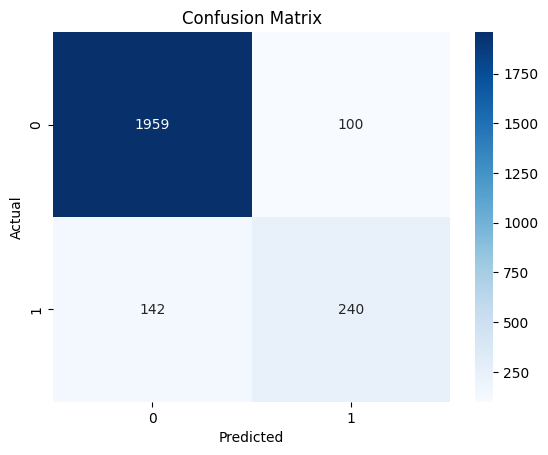

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
thresholds = [.2, .3, .4, .5, .6]

thresh_res = pd.DataFrame(columns=['threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Use pd.concat instead of the deprecated DataFrame.append
    new_row = pd.DataFrame([{
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }])
    thresh_res = pd.concat([thresh_res, new_row], ignore_index=True)

In [ ]:
thresh_res

,threshold,accuracy,precision,recall,f1,roc_auc
0,0.2,0.847603,0.507716,0.861257,0.638835,0.926728
1,0.3,0.896354,0.648961,0.735602,0.689571,0.926728
2,0.4,0.900041,0.680628,0.680628,0.680628,0.926728
3,0.5,0.900860,0.705882,0.628272,0.664820,0.926728
4,0.6,0.898402,0.753788,0.520942,0.616099,0.926728


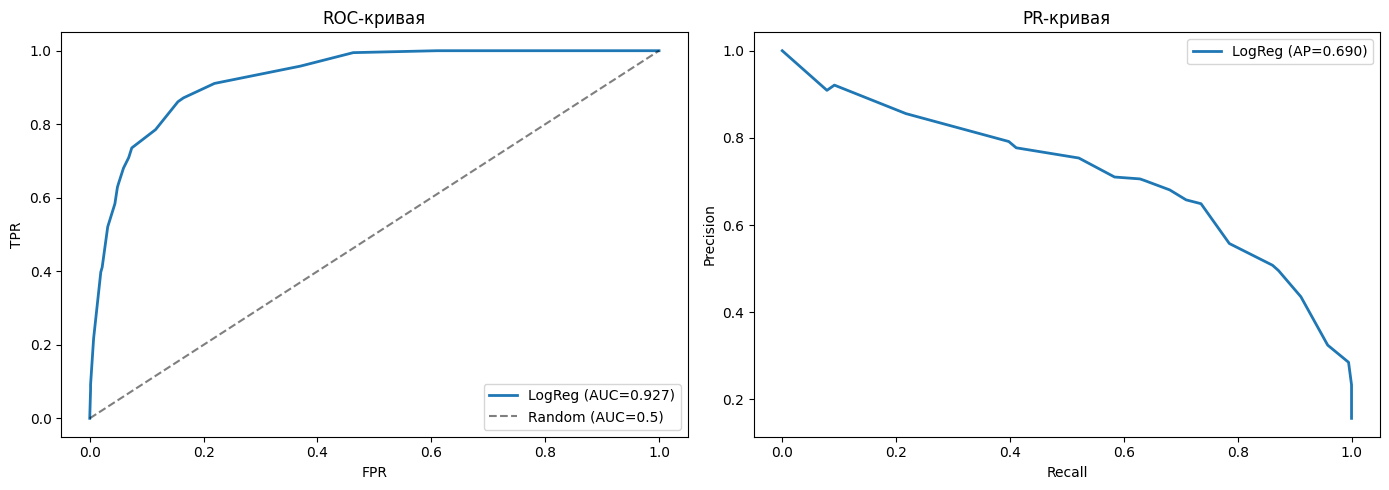

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_proba_bin = (y_prob >= .3).astype(int)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, linewidth=2, label=f'LogReg (AUC={roc_auc_score(y_test, y_prob):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(rec, prec, linewidth=2, label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

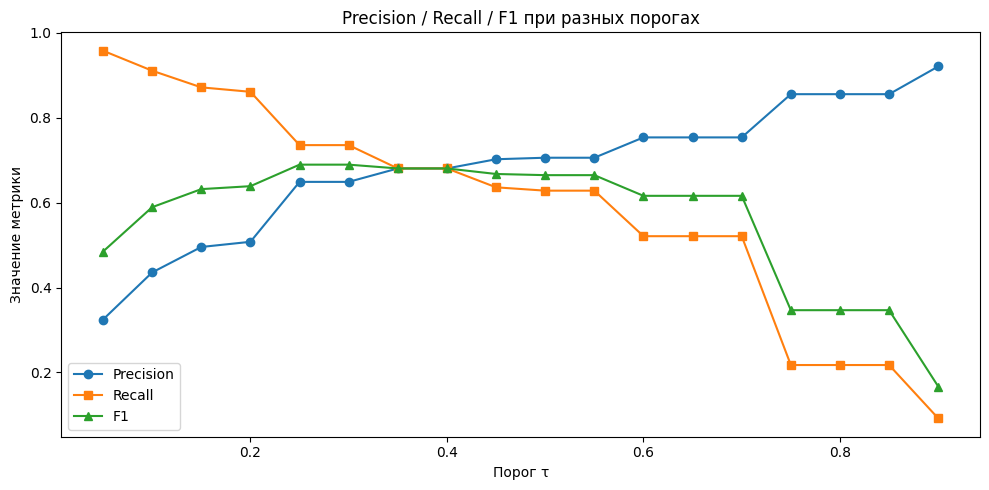

In [ ]:
thresholds = np.arange(0.05, 0.95, 0.05)

df_t = pd.DataFrame(columns=['precision', 'recall', 'f1'])

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Use pd.concat instead of the deprecated DataFrame.append
    new_row = pd.DataFrame([{
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }])
    df_t = pd.concat([df_t, new_row], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
ax.set_xlabel('Порог τ')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F1 при разных порогах')
ax.legend()
plt.tight_layout()
plt.show()

## Логистическая регрессия

In [35]:
from sklearn.linear_model import LogisticRegression

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categ_features
        ),
        (
            "num",
            StandardScaler(),
            quant_features
        )
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000
    ))
])

param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
0.9035433824881764
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      2059
           1       0.52      0.81      0.64       382

    accuracy                           0.86      2441
   macro avg       0.74      0.84      0.77      2441
weighted avg       0.89      0.86      0.87      2441

ROC-AUC: 0.9136074798674698


In [42]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

coef = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_model.named_steps["classifier"].coef_[0]
})

coef["Abs"] = coef["Coefficient"].abs()

coef.sort_values("Abs", ascending=False).head(20)

,Feature,Coefficient,Abs
67,num__PageValues,2.252312,2.252312
55,cat__Month_May,-0.797770,0.797770
66,num__ExitRates,-0.613536,0.613536
54,cat__Month_Mar,-0.607768,0.607768
31,cat__TrafficType_13,-0.597551,0.597551
56,cat__Month_Nov,0.586124,0.586124
50,cat__Month_Dec,-0.524070,0.524070
51,cat__Month_Feb,-0.446859,0.446859
38,cat__TrafficType_3,-0.333217,0.333217
28,cat__TrafficType_1,-0.265571,0.265571


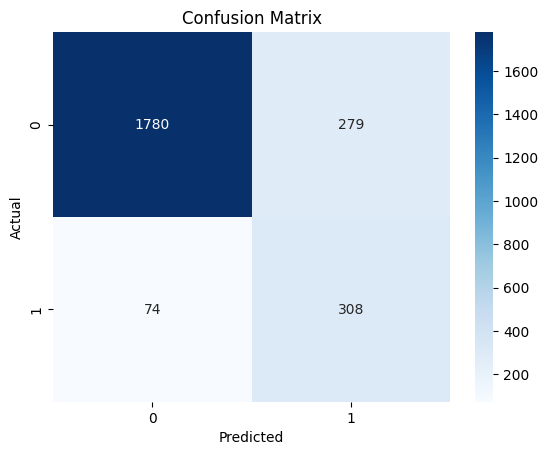

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

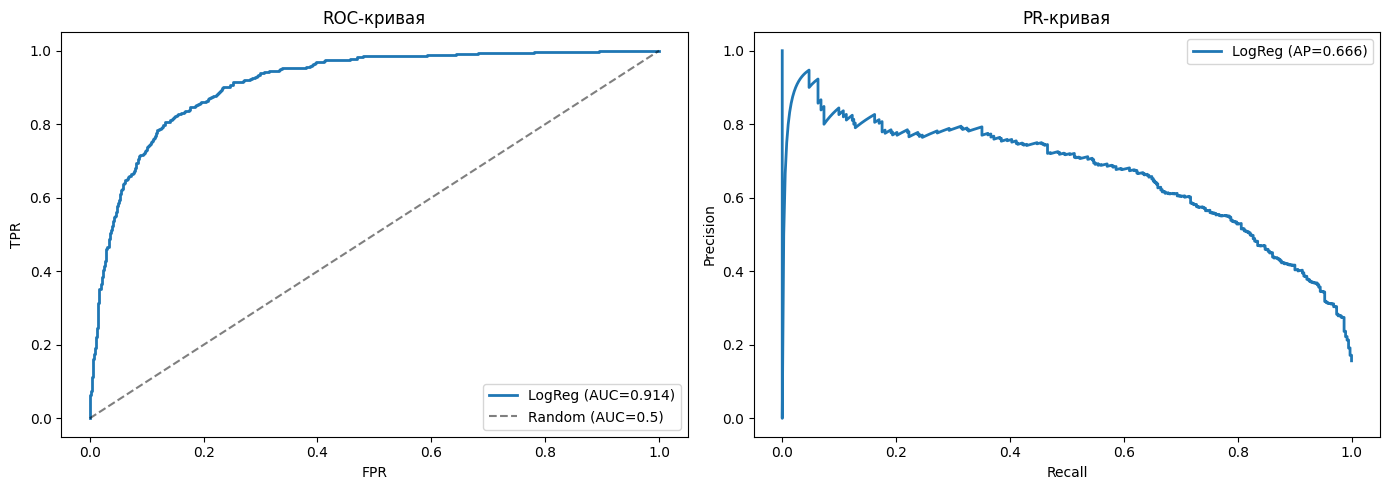

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, linewidth=2, label=f'LogReg (AUC={roc_auc_score(y_test, y_prob):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(rec, prec, linewidth=2, label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

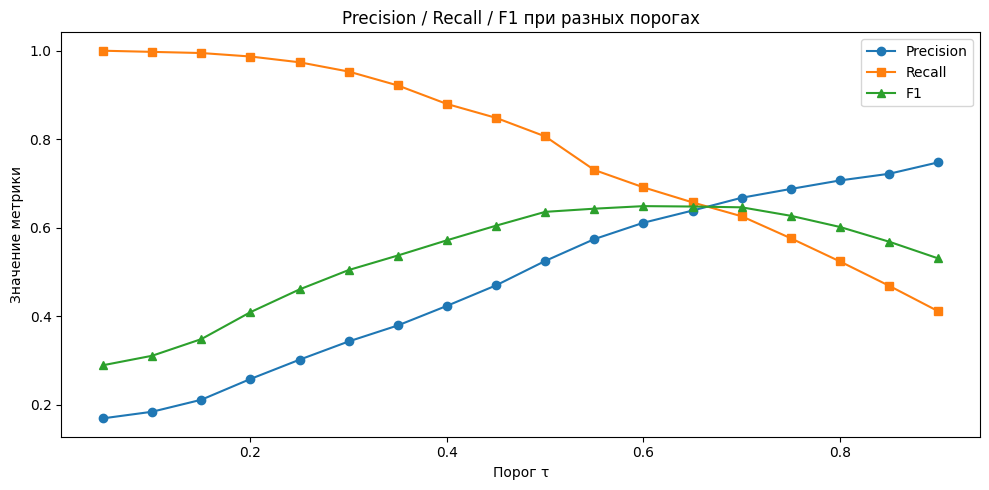

In [50]:
thresholds = np.arange(0.05, 0.95, 0.05)

df_t = pd.DataFrame(columns=['precision', 'recall', 'f1'])

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Use pd.concat instead of the deprecated DataFrame.append
    new_row = pd.DataFrame([{
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }])
    df_t = pd.concat([df_t, new_row], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
ax.set_xlabel('Порог τ')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F1 при разных порогах')
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
quant_features

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay']

In [54]:
log_features

['PageValues',
 'ProductRelated_Duration',
 'ProductRelated',
 'Administrative_Duration',
 'Informational_Duration']

In [57]:
quant_featurs = [f for f in quant_features if f not in log_features]
quant_featurs

['Administrative', 'Informational', 'BounceRates', 'ExitRates', 'SpecialDay']

In [58]:
log_transformer = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

num_transformer = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categ_features
        ),
        (
            "log",
            log_transformer,
            log_features
        ),
        (
            "num",
            num_transformer,
            quant_features
        )
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=3000
    ))
])

param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
0.9169088274204038
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2059
           1       0.56      0.81      0.66       382

    accuracy                           0.87      2441
   macro avg       0.76      0.85      0.79      2441
weighted avg       0.90      0.87      0.88      2441

ROC-AUC: 0.926526118254935


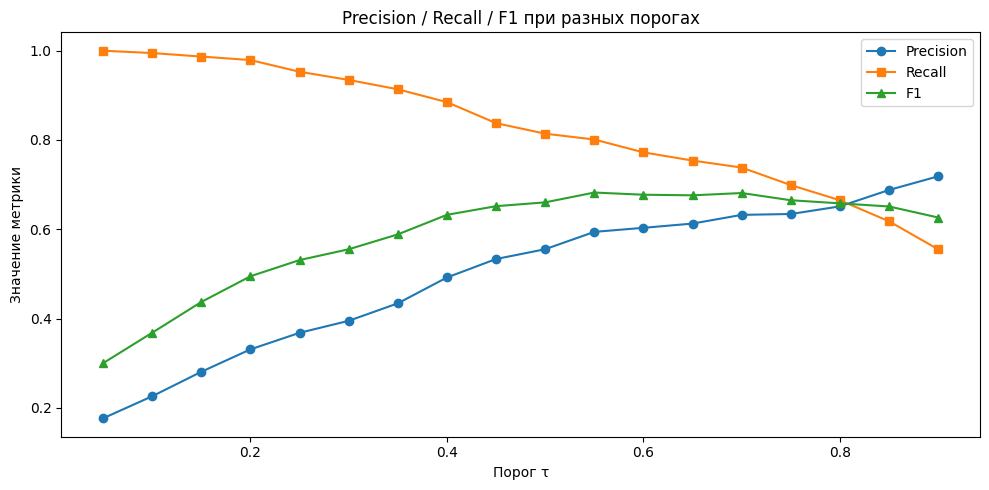

In [59]:
thresholds = np.arange(0.05, 0.95, 0.05)

df_t = pd.DataFrame(columns=['precision', 'recall', 'f1'])

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Use pd.concat instead of the deprecated DataFrame.append
    new_row = pd.DataFrame([{
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }])
    df_t = pd.concat([df_t, new_row], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
ax.set_xlabel('Порог τ')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F1 при разных порогах')
ax.legend()
plt.tight_layout()
plt.show()

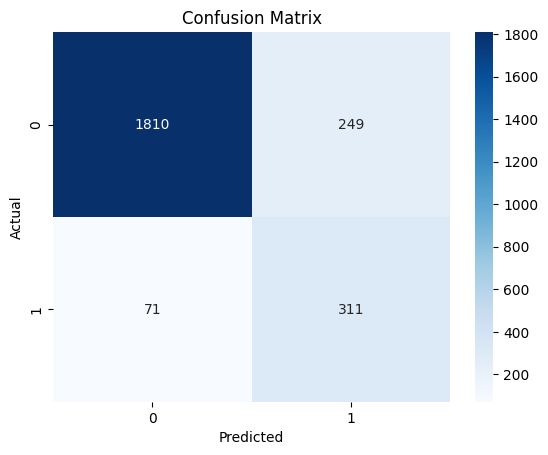

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()